<a href="https://colab.research.google.com/github/Nivedha2912/Dialogue-summarization-t5/blob/main/Copy_of_text_summarization_final_year_project_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dialogue Text Summarization using a Fine-Tuned LLM (T5)

**Final Year Project**

**Author:**Nivedha

This project fine-tunes a pre-trained Transformer language model (T5-small) to generate short summaries of two-person dialogues, using the SamSum dataset. It covers the full pipeline: data exploration, preprocessing, fine-tuning, quantitative evaluation (ROUGE), and an interactive demo for testing the model on new input.

**Pipeline:** Load data → Explore → Preprocess & Tokenize → Fine-tune T5 → Evaluate → Demo

## 1. Setup

In [ ]:
# Confirm a GPU is attached (Runtime -> Change runtime type -> GPU)
!nvidia-smi


Sun Sep 13 16:18:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q transformers datasets evaluate rouge-score gradio accelerate


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
import evaluate

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)


Using device: cuda


In [ ]:
# Mount Google Drive so the trained model and checkpoints survive disconnects
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/final_year_project/t5_samsum'


Mounted at /content/drive


## 2. Load and Explore the Dataset

We use [SamSum](https://huggingface.co/datasets/knkarthick/samsum): ~16k short messenger-style dialogues, each paired with a human-written summary.

In [ ]:
raw_datasets = load_dataset('knkarthick/samsum')

train_df = raw_datasets['train'].to_pandas()
test_df = raw_datasets['test'].to_pandas()
val_df = raw_datasets['validation'].to_pandas()

print('Train:', train_df.shape, '| Test:', test_df.shape, '| Validation:', val_df.shape)
train_df.head()


README.md:   0%|          | 0.00/4.36k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/9.26M [00:00<?, ?B/s]

validation.csv:   0%|          | 0.00/504k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/522k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

Train: (14731, 3) | Test: (819, 3) | Validation: (818, 3)


,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\nJ...,Amanda baked cookies and will bring Jerry some...
1,13728867,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
2,13681000,"Tim: Hi, what's up?\nKim: Bad mood tbh, I was ...",Kim may try the pomodoro technique recommended...
3,13730747,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
4,13728094,Sam: hey overheard rick say something\nSam: i...,"Sam is confused, because he overheard Rick com..."


In [ ]:
# Check for missing values and duplicates
print('Missing values:\n', train_df.isnull().sum())
print('\nDuplicate rows:', train_df.duplicated().sum())


Missing values:
 id          0
dialogue    0
summary     0
dtype: int64

Duplicate rows: 0


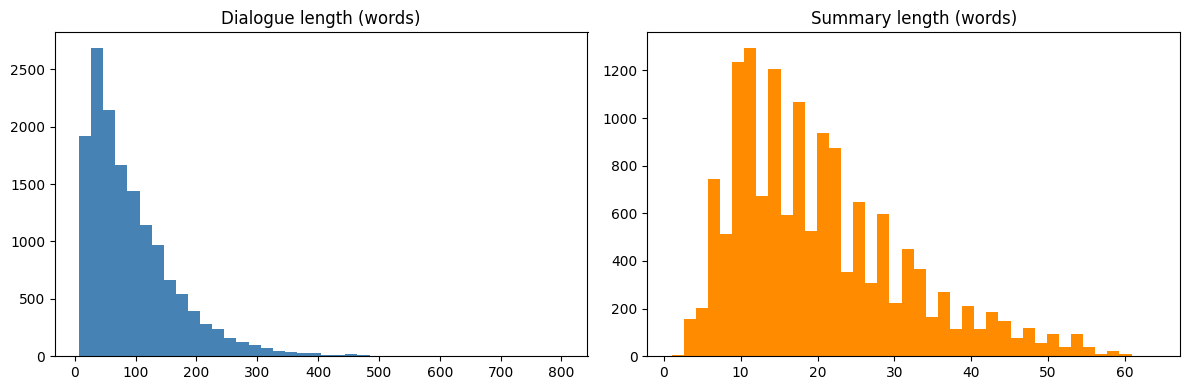

Median dialogue length: 73.0
Median summary length: 18.0


In [ ]:
# Distribution of dialogue and summary lengths (in words)
train_df['dialogue_len'] = train_df['dialogue'].astype(str).apply(lambda x: len(x.split()))
train_df['summary_len'] = train_df['summary'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df['dialogue_len'], bins=40, color='steelblue')
axes[0].set_title('Dialogue length (words)')
axes[1].hist(train_df['summary_len'], bins=40, color='darkorange')
axes[1].set_title('Summary length (words)')
plt.tight_layout()
plt.show()

print('Median dialogue length:', train_df['dialogue_len'].median())
print('Median summary length:', train_df['summary_len'].median())


In [ ]:
# Drop rows with missing/empty dialogue or summary, across all splits
for name, df in [('train', train_df), ('test', test_df), ('val', val_df)]:
    before = len(df)
    df.dropna(subset=['dialogue', 'summary'], inplace=True)
    df = df[(df['dialogue'].str.strip() != '') & (df['summary'].str.strip() != '')]
    print(f'{name}: {before} -> {len(df)} rows after cleaning')


train: 14731 -> 14731 rows after cleaning
test: 819 -> 819 rows after cleaning
val: 818 -> 818 rows after cleaning


## 3. Preprocessing and Tokenization

T5 treats every task as text-to-text, so we prefix each dialogue with the instruction `"summarize: "` before tokenizing. Inputs and targets are truncated to sensible max lengths.

In [ ]:
MODEL_CHECKPOINT = 't5-small'
MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 64
PREFIX = 'summarize: '

tokenizer = T5Tokenizer.from_pretrained(MODEL_CHECKPOINT)


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

In [ ]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df[['dialogue', 'summary']].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[['dialogue', 'summary']].reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df[['dialogue', 'summary']].reset_index(drop=True))

def preprocess_function(examples):
    inputs = [PREFIX + doc for doc in examples['dialogue']]
    model_inputs = tokenizer(inputs, max_length=MAX_INPUT_LENGTH, truncation=True)

    labels = tokenizer(text_target=examples['summary'], max_length=MAX_TARGET_LENGTH, truncation=True)
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

tokenized_train = train_ds.map(preprocess_function, batched=True, remove_columns=['dialogue', 'summary'])
tokenized_test = test_ds.map(preprocess_function, batched=True, remove_columns=['dialogue', 'summary'])
tokenized_val = val_ds.map(preprocess_function, batched=True, remove_columns=['dialogue', 'summary'])


Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

## 4. Fine-Tuning the Model

We load a pre-trained T5-small checkpoint and fine-tune it on SamSum using the `Seq2SeqTrainer` API, evaluating with ROUGE at the end of each epoch.

In [ ]:
model = T5ForConditionalGeneration.from_pretrained(MODEL_CHECKPOINT).to(device)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  242MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
rouge = evaluate.load('rouge')

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    result = {k: round(v * 100, 2) for k, v in result.items()}

    pred_lens = [len(pred.split()) for pred in decoded_preds]
    result['gen_len'] = round(np.mean(pred_lens), 2)
    return result


In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir=SAVE_DIR,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='rouge1',
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)


In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,1.914334,1.718901,43.820000,19.910000,36.280000,36.240000,12.570000
2,1.726592,1.667358,43.770000,20.050000,36.410000,36.370000,12.420000
3,1.584297,1.661976,44.340000,20.430000,36.800000,36.750000,12.260000


/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=5526, training_loss=1.774039790028901, metrics={'train_runtime': 917.4039, 'train_samples_per_second': 48.172, 'train_steps_per_second': 6.024, 'total_flos': 3845383866974208.0, 'train_loss': 1.774039790028901, 'epoch': 3.0})

## 5. Evaluation

Evaluate on the held-out validation set (kept separate from the test set used during training).

In [ ]:
val_results = trainer.evaluate(eval_dataset=tokenized_val)
val_results


Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1.584297,1.650695,3,45.700000,22.630000,38.560000,38.550000,12.220000


{'eval_loss': 1.6506946086883545,
 'eval_rouge1': 45.7,
 'eval_rouge2': 22.63,
 'eval_rougeL': 38.56,
 'eval_rougeLsum': 38.55,
 'eval_gen_len': 12.22}

In [ ]:
# Save the fine-tuned model and tokenizer
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print('Model saved to', SAVE_DIR)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/final_year_project/t5_samsum


## 6. Baseline Comparison (Before vs After Fine-Tuning)

To show the fine-tuning actually helped, we compare ROUGE scores of the base, untrained `t5-small` model against our fine-tuned version on the same validation examples.

In [ ]:
base_model = T5ForConditionalGeneration.from_pretrained(MODEL_CHECKPOINT).to(device)

def generate_summary(model, dialogue, max_length=64):
    input_text = PREFIX + dialogue
    inputs = tokenizer(input_text, return_tensors='pt', truncation=True, max_length=MAX_INPUT_LENGTH).to(device)
    output_ids = model.generate(**inputs, max_length=max_length, num_beams=4)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

sample = val_df.iloc[0]
print('DIALOGUE:\n', sample['dialogue'])
print('\nREFERENCE SUMMARY:\n', sample['summary'])
print('\nBASE MODEL (no fine-tuning):\n', generate_summary(base_model, sample['dialogue']))
print('\nFINE-TUNED MODEL:\n', generate_summary(model, sample['dialogue']))


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

DIALOGUE:
 A: Hi Tom, are you busy tomorrow’s afternoon?
B: I’m pretty sure I am. What’s up?
A: Can you go with me to the animal shelter?.
B: What do you want to do?
A: I want to get a puppy for my son.
B: That will make him so happy.
A: Yeah, we’ve discussed it many times. I think he’s ready now.
B: That’s good. Raising a dog is a tough issue. Like having a baby ;-) 
A: I'll get him one of those little dogs.
B: One that won't grow up too big;-)
A: And eat too much;-))
B: Do you know which one he would like?
A: Oh, yes, I took him there last Monday. He showed me one that he really liked.
B: I bet you had to drag him away.
A: He wanted to take it home right away ;-).
B: I wonder what he'll name it.
A: He said he’d name it after his dead hamster – Lemmy  - he's  a great Motorhead fan :-)))

REFERENCE SUMMARY:
 A will go to the animal shelter tomorrow to get a puppy for her son. They already visited the shelter last Monday and the son chose the puppy. 

BASE MODEL (no fine-tuning):
 a: I 

## 7. Interactive Demo (for testing your own dialogues)

A small Gradio interface so you (or anyone reviewing the project) can type in a dialogue and see the generated summary live — useful for a project demo/viva.

In [ ]:
import gradio as gr

def summarize_dialogue(dialogue_text):
    if not dialogue_text.strip():
        return 'Please enter a dialogue.'
    return generate_summary(model, dialogue_text)

demo = gr.Interface(
    fn=summarize_dialogue,
    inputs=gr.Textbox(lines=8, placeholder='Paste a dialogue here...', label='Dialogue'),
    outputs=gr.Textbox(label='Generated Summary'),
    title='Dialogue Summarizer (Fine-Tuned T5)',
    description='Final year project: text summarization using a fine-tuned LLM.'
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4eec8ab1fc34b6f585.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 8. Conclusion

_TODO: write your own conclusion — report your final ROUGE-1/2/L scores, note the improvement over the base model from Section 6, and discuss limitations (e.g. struggles with very long dialogues, or informal/slang language) and possible future work (larger model, more epochs, multi-turn context handling)._